In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

dataset_folder = r"C:\Users\michael\Desktop\IDX Exchange\Files\datasets"
os.chdir(dataset_folder)

In [3]:
df_sold = pd.read_csv("CRMLSSold_1.csv", low_memory = False)
df_listings = pd.read_csv("CRMLSListing_1.csv", low_memory = False)

In [4]:
print("Property Types")
print(f"- CRMLSSold: {sorted(df_sold["PropertyType"].unique())}")
print(f"- CRMLSListings: {sorted(df_listings["PropertyType"].unique())}")

Property Types
- CRMLSSold: ['BusinessOpportunity', 'CommercialLease', 'CommercialSale', 'Land', 'ManufacturedInPark', 'Residential', 'ResidentialIncome', 'ResidentialLease']
- CRMLSListings: ['BusinessOpportunity', 'CommercialLease', 'CommercialSale', 'Land', 'ManufacturedInPark', 'Residential', 'ResidentialIncome', 'ResidentialLease']


In [5]:
print("Residential Property Type Share")
print(f"- CRMLSSold: {len(df_sold[df_sold.PropertyType == "Residential"]) / len(df_sold) * 100:.3f}%")
print(f"- CRMLSListings: {len(df_listings[df_listings.PropertyType == "Residential"]) / len(df_listings) * 100:.3f}%")

Residential Property Type Share
- CRMLSSold: 66.921%
- CRMLSListings: 65.797%


In [6]:
df_sold = df_sold[df_sold.PropertyType == "Residential"]
df_listings = df_listings[df_listings.PropertyType == "Residential"]

In [7]:
print("CRMLSSold")
print(f"- Rows: {len(df_sold)}")
print(f"- Columns: {len(df_sold.columns)}")

print("CRMLSListings")
print(f"- Rows: {len(df_listings)}")
print(f"- Columns: {len(df_listings.columns)}")

CRMLSSold
- Rows: 455658
- Columns: 79
CRMLSListings
- Rows: 504466
- Columns: 81


In [8]:
na_count = []
na_percent = []
na_flag = []

for column in df_sold:
    na_count_num = df_sold[column].isna().sum()
    na_count.append(na_count_num)
    na_percent_num = na_count_num / len(df_sold) * 100
    na_percent.append(na_percent_num)
    if na_percent_num > 90:
        na_flag.append(1)
    else:
        na_flag.append(0)

null_summary_sold = pd.DataFrame({"ColumnName": df_sold.columns,
                     "MissingCount": na_count,
                     "MissingPercent": na_percent,
                     "Flag": na_flag})

# "Flag" is a boolean that corresponds to whether MissingPercent is greater than 90.
null_summary_sold[null_summary_sold.Flag == 1]

,ColumnName,MissingCount,MissingPercent,Flag
4,WaterfrontYN,455366,99.935917,1
5,BasementYN,446759,98.047000,1
29,FireplacesTotal,455658,100.000000,1
31,AboveGradeFinishedArea,455658,100.000000,1
34,TaxAnnualAmount,455658,100.000000,1
40,BuilderName,432314,94.876859,1
50,TaxYear,455658,100.000000,1
51,BuildingAreaTotal,422800,92.788890,1
54,ElementarySchoolDistrict,455658,100.000000,1
55,CoBuyerAgentFirstName,413553,90.759517,1


In [9]:
na_count = []
na_percent = []
na_flag = []

for column in df_listings:
    na_count_num = df_listings[column].isna().sum()
    na_count.append(na_count_num)
    na_percent_num = na_count_num / len(df_listings) * 100
    na_percent.append(na_percent_num)
    if na_percent_num > 90:
        na_flag.append(1)
    else:
        na_flag.append(0)

null_summary_listings = pd.DataFrame({"ColumnName": df_listings.columns,
                     "MissingCount": na_count,
                     "MissingPercent": na_percent,
                     "Flag": na_flag})

# "Flag" is a boolean that corresponds to whether MissingPercent is greater than 90.
null_summary_listings[null_summary_listings.Flag == 1]

,ColumnName,MissingCount,MissingPercent,Flag
22,FireplacesTotal,504466,100.000000,1
24,AboveGradeFinishedArea,504466,100.000000,1
27,TaxAnnualAmount,504466,100.000000,1
35,BuilderName,479787,95.107896,1
47,TaxYear,504466,100.000000,1
48,BuildingAreaTotal,465919,92.358851,1
52,ElementarySchoolDistrict,504466,100.000000,1
53,CoBuyerAgentFirstName,465224,92.221081,1
56,BelowGradeFinishedArea,501335,99.379344,1
57,BusinessType,504466,100.000000,1


In [10]:
# Removes all fields with >90% missing values (only run this block once).

sold_flagged_columns = list(null_summary_sold[null_summary_sold.Flag == 1]["ColumnName"])
df_sold = df_sold.drop(columns = sold_flagged_columns)

listings_flagged_columns = list(null_summary_listings[null_summary_listings.Flag == 1]["ColumnName"])
df_listings = df_listings.drop(columns = listings_flagged_columns)

In [11]:
df_sold[["ClosePrice", "LivingArea", "DaysOnMarket"]].describe().style.format("{:,.3f}")

,ClosePrice,LivingArea,DaysOnMarket
count,"455,656.000","455,388.000","455,658.000"
mean,"1,124,046.572","1,900.139",37.629
std,"1,264,028.838","25,240.962",53.789
min,525.000,0.000,-288.000
25%,"571,745.750","1,248.000",8.000
50%,"815,000.000","1,643.000",19.000
75%,"1,280,000.000","2,220.000",49.000
max,"110,000,000.000","17,021,321.000","12,430.000"


In [12]:
df_sold.to_csv("CRMLSSold_2.csv", index = False)
df_listings.to_csv("CRMLSListing_2.csv", index = False)

In [13]:
sold_above_list_price = len(df_sold[df_sold.ClosePrice > df_sold.ListPrice]) / len(df_sold) * 100
sold_at_list_price = len(df_sold[df_sold.ClosePrice == df_sold.ListPrice]) / len(df_sold) * 100
sold_below_list_price = len(df_sold[df_sold.ClosePrice < df_sold.ListPrice]) / len(df_sold) * 100

print("Percentage of homes sold ___ list price:")
print(f"- ABOVE: {sold_above_list_price:.3f}%")
print(f"- AT: {sold_at_list_price:.3f}%")
print(f"- BELOW: {sold_below_list_price:.3f}%")

Percentage of homes sold ___ list price:
- ABOVE: 39.513%
- AT: 17.661%
- BELOW: 42.826%


In [14]:
# Are there any apparent date consistency issues (e.g., close date before listing date)?
df_sold[["DaysOnMarket", "ListingContractDate", "CloseDate"]][df_sold.ListingContractDate > df_sold.CloseDate]

,DaysOnMarket,ListingContractDate,CloseDate
27,0,2024-01-31,2024-01-30
124,0,2024-01-26,2024-01-25
1985,0,2024-01-02,2024-01-01
37650,0,2024-04-08,2024-03-29
37883,0,2024-03-21,2024-03-20
...,...,...,...
631667,0,2026-05-18,2026-05-06
632377,0,2026-05-08,2026-05-07
655487,0,2026-06-25,2026-06-23
655576,0,2026-06-22,2026-06-17


In [15]:
(df_sold.groupby("CountyOrParish")["ListPrice"]
    .median()
    .sort_values(ascending = False)
    .reset_index()
    .head()
    .rename(columns = {"ListPrice": "MedianListPrice"})
    .style.format({"MedianListPrice": "{:,.3f}"}))

,CountyOrParish,MedianListPrice
0,Del Norte,"7,717,500.000"
1,San Mateo,"1,592,500.000"
2,Santa Clara,"1,488,000.000"
3,Alpine,"1,295,000.000"
4,Santa Cruz,"1,195,000.000"


In [16]:
(df_sold.groupby("CountyOrParish")["ClosePrice"]
    .median()
    .sort_values(ascending = False)
    .reset_index()
    .head()
    .rename(columns = {"ClosePrice": "MedianClosePrice"})
    .style.format({"MedianClosePrice": "{:,.3f}"}))

,CountyOrParish,MedianClosePrice
0,Del Norte,"6,742,500.000"
1,San Mateo,"1,650,000.000"
2,Santa Clara,"1,540,000.000"
3,Orange,"1,180,000.000"
4,Santa Cruz,"1,177,000.000"


In [17]:
key_numeric_fields = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea", "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]

In [18]:
df_sold[key_numeric_fields].describe().loc[["25%", "50%", "75%"]].style.format("{:,.3f}")

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
25%,"571,745.750","575,000.000","580,000.000","1,248.000",0.120,3.000,2.000,8.000,"1,960.000"
50%,"815,000.000","800,000.000","819,999.000","1,643.000",0.167,3.000,2.000,19.000,"1,979.000"
75%,"1,280,000.000","1,275,000.000","1,295,000.000","2,220.000",0.276,4.000,3.000,49.000,"1,999.000"


In [98]:
def remove_outliers(df, field):
    Q1 = df[field].quantile(0.25)
    Q3 = df[field].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[field] >= lower) & (df[field] <= upper)]
    return df


def graphs(field):
    fig, axes = plt.subplots(2, 2, figsize = (10, 4))
    df_sold_trimmed = remove_outliers(df_sold, field)
    df_listings_trimmed = remove_outliers(df_listings, field)

    def format_y_axis(ax):
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.ticklabel_format(style = "plain", axis = "y", useOffset = False)

    sns.histplot(data = df_sold_trimmed, x = field, ax = axes[0, 0])
    axes[0, 0].set_title("Sold (Histogram)")
    format_y_axis(axes[0, 0])
    
    sns.histplot(data = df_listings_trimmed, x = field, ax = axes[0, 1])
    axes[0, 1].set_title("Listings (Histogram)")
    format_y_axis(axes[0, 1])
    
    sns.boxplot(data = df_sold_trimmed, x = field, ax = axes[1, 0], showfliers = False)
    axes[1, 0].set_title("Sold (Boxplot)")
    format_y_axis(axes[1, 0])
    
    sns.boxplot(data = df_listings_trimmed, x = field, ax = axes[1, 1], showfliers = False)
    axes[1, 1].set_title("Listings (Boxplot)")
    format_y_axis(axes[1, 1])
    
    plt.tight_layout()

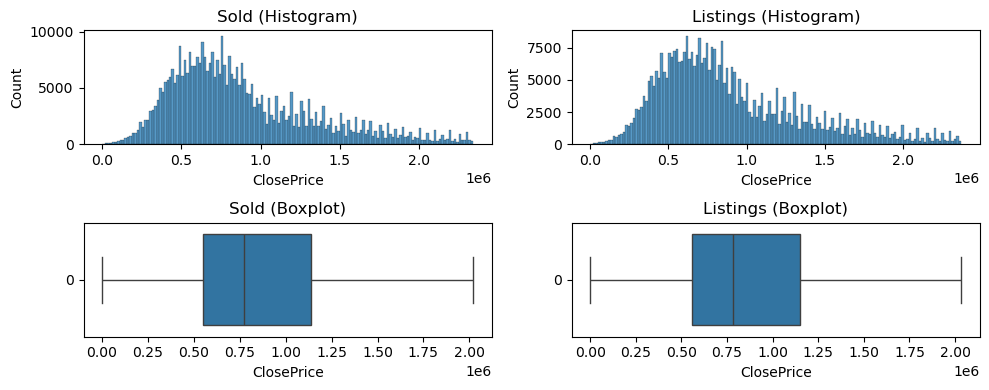

In [99]:
graphs("ClosePrice")

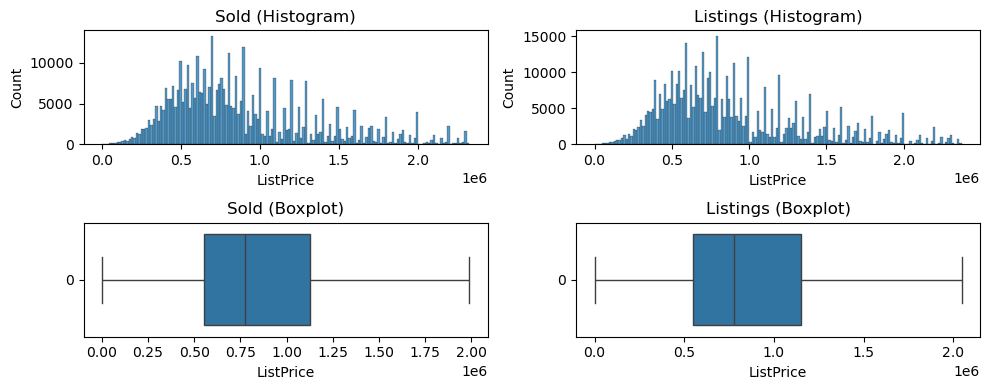

In [100]:
graphs("ListPrice")

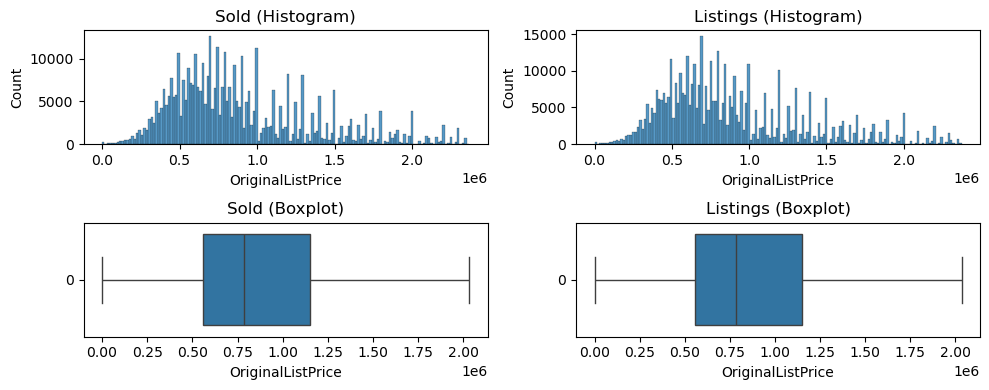

In [101]:
graphs("OriginalListPrice")

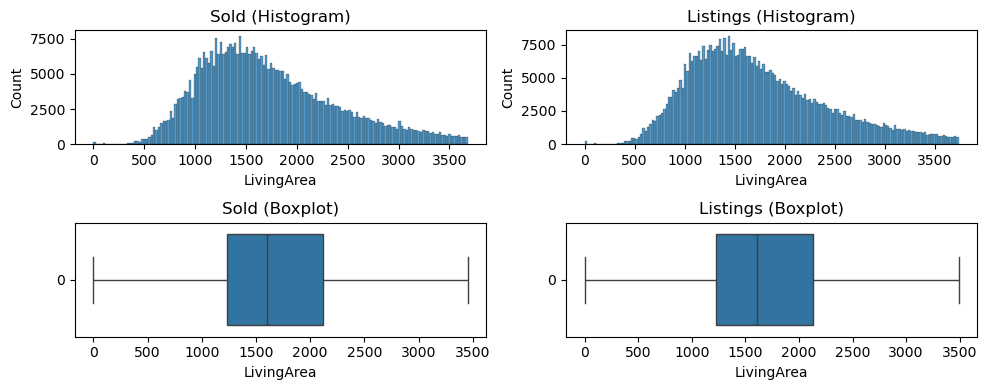

In [102]:
graphs("LivingArea")

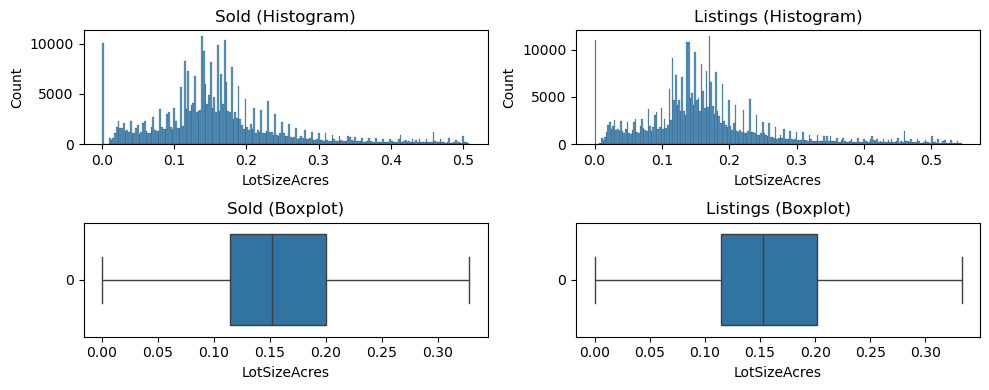

In [103]:
graphs("LotSizeAcres")

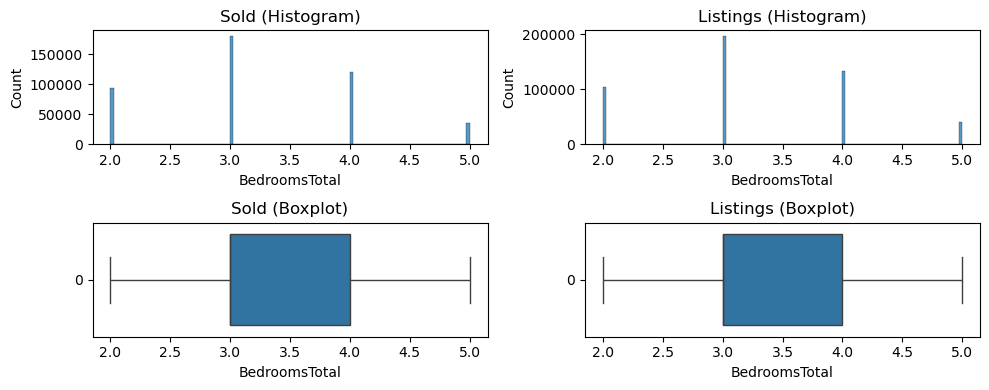

In [104]:
graphs("BedroomsTotal")

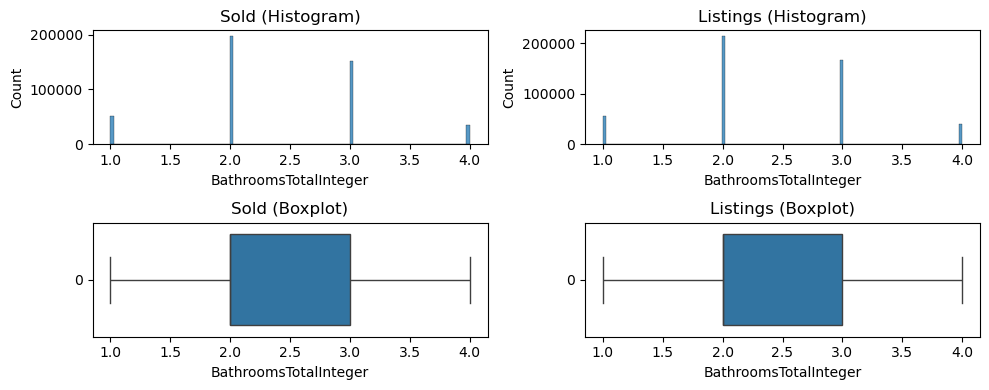

In [105]:
graphs("BathroomsTotalInteger")

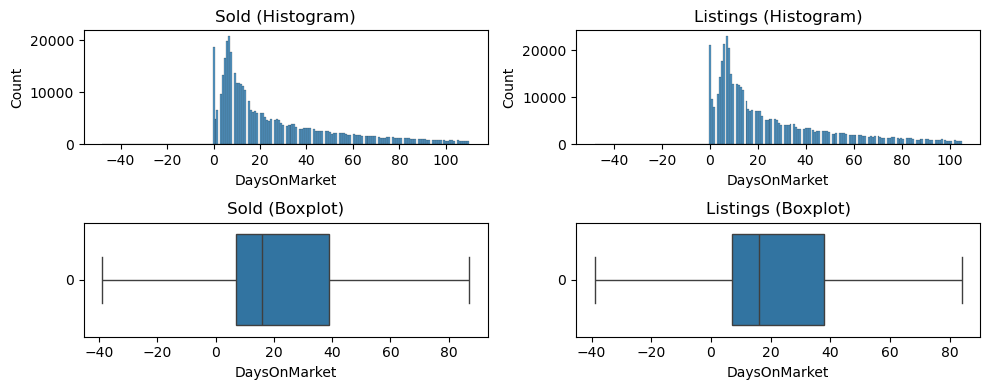

In [106]:
graphs("DaysOnMarket")

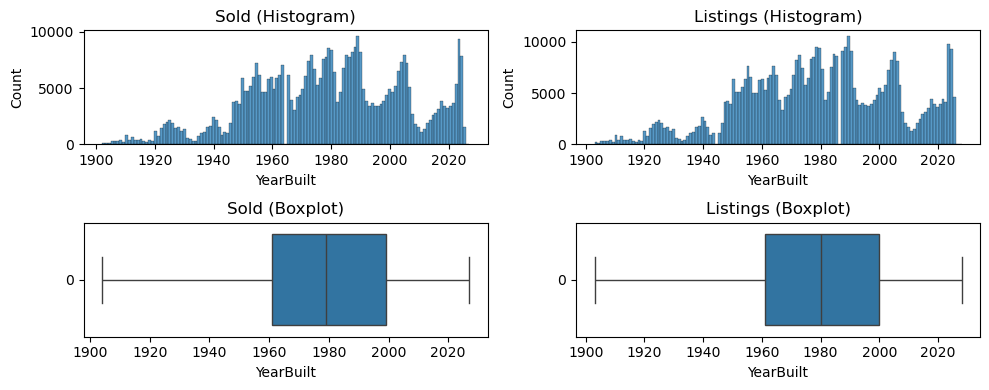

In [107]:
graphs("YearBuilt")